# Tutorial model run for the GeoEnthalpyDelta component.

Builds a small delta prograding from a west-edge feeder onto a planar,
fixed basement, with a flat sea level, then plots map-view thickness and a
centerline cross-section (basement, topography, sea level).

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from landlab import RasterModelGrid
from landlab.components import GeoEnthalpyDelta

## Grid setup

For this example, we only need a small size grid so 50x50 looks good enough.
Setting up the grid using the Landlab grid component.

We also want to extract x axis so we can set up a basement for the model.
Since the basement is a plannar with a downhill slope, we have it slope `m=-1`

```basement = -mx```

In [2]:
nrows, ncols = 50, 50
dx = dy = 0.2
grid = RasterModelGrid((nrows, ncols), xy_spacing=dx) # hummm no option for (dx,dy)?

x = grid.x_of_node.reshape(grid.shape)
basement = grid.add_zeros("basement__elevation", at="node")
m1 = -1
m2 = 0.02
break_at = nrows*dx / 3
x_flat = x.reshape(-1)
basement[:] = np.where(
    x_flat <= break_at,
    m1 * x_flat,
    m1 * break_at + m2 * (x_flat - break_at),
)

In [3]:
%matplotlib inline
from landlab.plot import imshow_grid

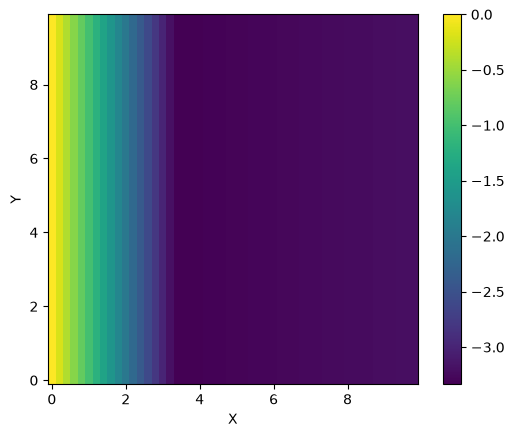

In [4]:
imshow_grid(grid, "basement__elevation", cmap="viridis")

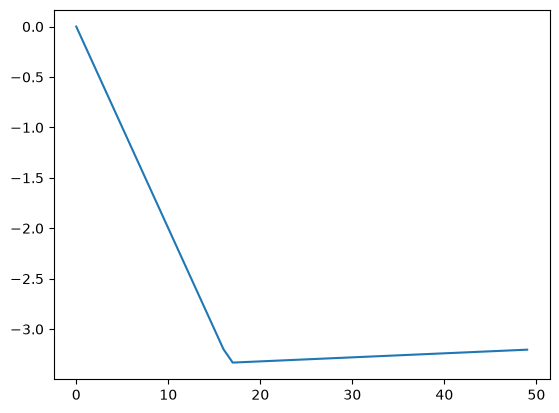

In [5]:
plt.plot(grid.at_node['basement__elevation'].reshape(grid.shape)[1,:])

Component calling

In [6]:
grid

RasterModelGrid((50, 50), xy_spacing=(np.float64(0.2), np.float64(0.2)), xy_of_lower_left=(np.float64(0.0), np.float64(0.0)))

In [7]:
sea_level = -4.0
esd = GeoEnthalpyDelta(
    grid,
    sediment_influx=0.5,
    feeder_width=1.0,
    sea_level_start=sea_level,
    sea_level_rise_rate=0.0,
    topset_threshold_x=0.1,
    topset_threshold_y=0.1,
    foreset_threshold_x=2.0,
    foreset_threshold_y=2.0,
    topset_diffusivity_x=1.0,
    topset_diffusivity_y=1.0,
    foreset_diffusivity_x=1.0,
    foreset_diffusivity_y=1.0,
)

dt = esd.calc_stable_time_step()
nsteps = 2500
print(f"dt = {dt:.5g}, running {nsteps} steps (t_end = {nsteps * dt:.3g}) ...")

dt = 0.004, running 2500 steps (t_end = 10) ...


This will take a while, but your should see `done in #.# s` meaning the run is completed

In [8]:
t0 = time.time()
volume_history = []
time_history = []
for step in range(nsteps):
    esd.run_one_step(dt)
    if step % 25 == 0:
        vol = np.sum(grid.at_node["sediment__thickness"]) * dx * dy
        volume_history.append(vol)
        time_history.append(esd.time_elapsed)
print(f"done in {time.time() - t0:.2f} s")

done in 9.38 s


## Mass Balance
Checking if the final output match with the expected output

In [9]:
expected_volume = 0.5 * nsteps * dt
final_volume = np.sum(grid.at_node["sediment__thickness"]) * dx * dy
np.isclose(final_volume, expected_volume, rtol=1e-6)


np.True_

Check the 3 output of the component 
1. basement__elevation

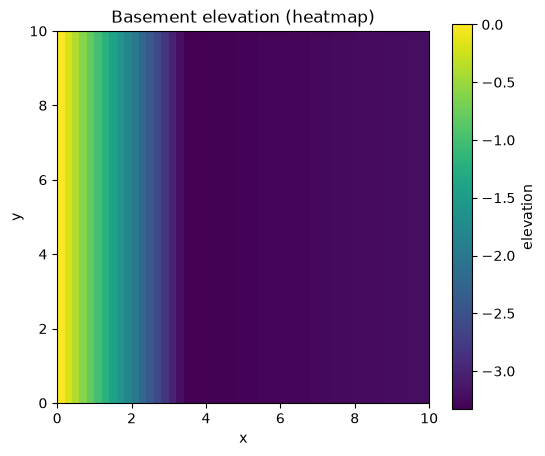

In [10]:
basement = grid.at_node["basement__elevation"].reshape(grid.shape)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(basement, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="viridis", aspect="equal")
ax.set_title("Basement elevation (heatmap)")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="elevation")
plt.show()

2. `grid.at_node["sediment__thickness"]`


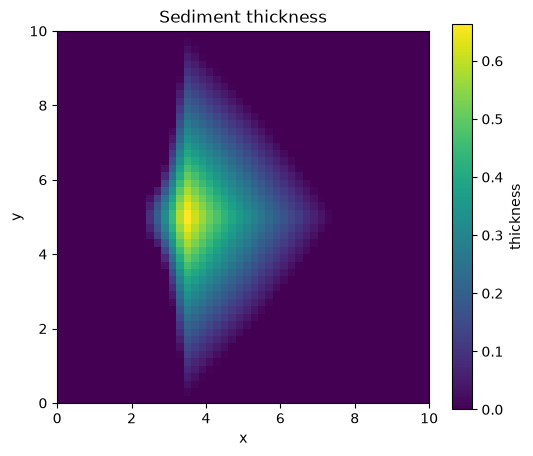

In [11]:
Hthickness = grid.at_node["sediment__thickness"].reshape(grid.shape)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Hthickness, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="viridis", aspect="equal")
ax.set_title("Sediment thickness")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="thickness")
plt.show()

3. `grid.at_node["topographic__elevation"]`

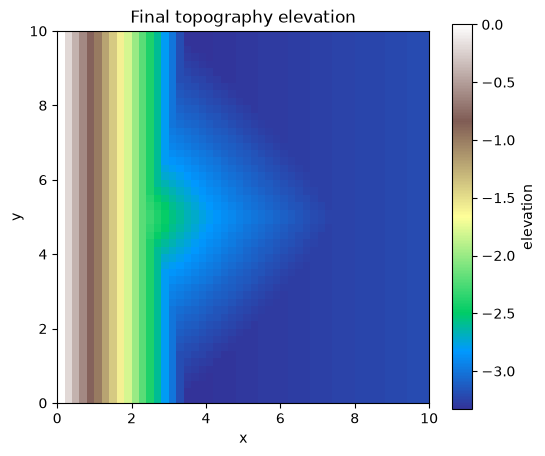

In [12]:
final_topography = grid.at_node["topographic__elevation"].reshape(grid.shape)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(final_topography, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="terrain", aspect="equal")
ax.set_title("Final topography elevation")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="elevation")
plt.show()

## Comprehensive Plots

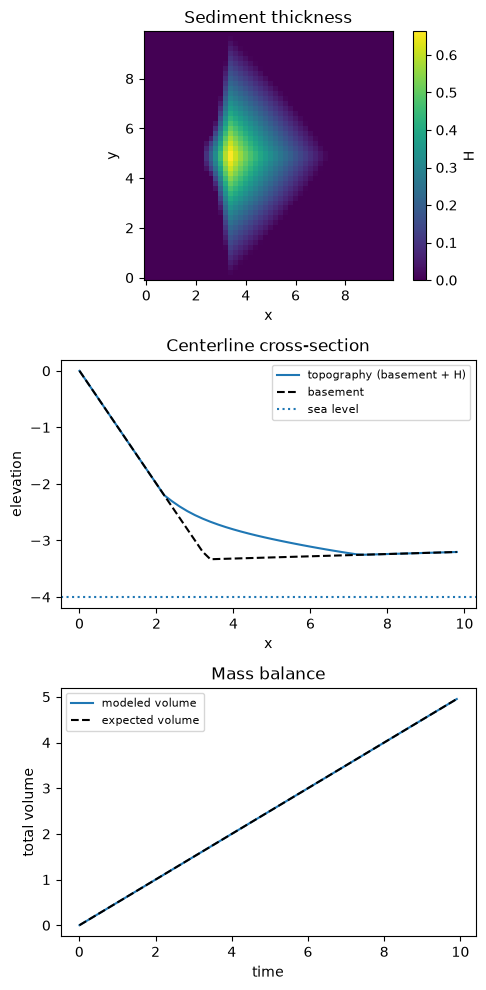

In [13]:
H = Hthickness
eta = final_topography
final_sea_level = sea_level + esd.sea_level_rise_rate * esd.time_elapsed
X = grid.x_of_node.reshape(grid.shape)
Y = grid.y_of_node.reshape(grid.shape)
j_mid = nrows // 2

fig, axes = plt.subplots(3, 1, figsize=(5, 10))

im = axes[0].pcolormesh(X, Y, H, shading="auto", cmap="viridis")
axes[0].set_title("Sediment thickness")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
fig.colorbar(im, ax=axes[0], label="H")

axes[1].plot(X[j_mid], eta[j_mid], label="topography (basement + H)")
axes[1].plot(X[j_mid], basement[j_mid],
             "k--", label="basement")
axes[1].axhline(final_sea_level,color="tab:blue",linestyle=":",label="sea level")
axes[1].set_title("Centerline cross-section")
axes[1].set_xlabel("x")
axes[1].set_ylabel("elevation")
axes[1].legend(fontsize=8)

axes[2].plot(time_history, volume_history, label="modeled volume")
axes[2].plot(time_history, [0.5 * t for t in time_history], "k--", label="expected volume")
axes[2].set_title("Mass balance")
axes[2].set_xlabel("time")
axes[2].set_ylabel("total volume")
axes[2].legend(fontsize=8)

fig.tight_layout()

In [14]:
esd = GeoEnthalpyDelta(
    grid,
    sediment_influx=0.5,
    feeder_width=1.0,
    sea_level_start=sea_level,
    sea_level_rise_rate=-0.2,
    topset_threshold_x=0.1,
    topset_threshold_y=0.1,
    foreset_threshold_x=2.0,
    foreset_threshold_y=2.0,
    topset_diffusivity_x=1.0,
    topset_diffusivity_y=1.0,
    foreset_diffusivity_x=1.0,
    foreset_diffusivity_y=1.0,
)